In [127]:
from sklearn import linear_model
import sys
from sklearn import linear_model
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import pyreadr 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f
from scipy.stats import chi2
import math
from scipy.stats import gmean
import re


In [128]:
nl = pd.read_json('data_prepared/NL_prepared_data')
ge = pd.read_json('data_prepared/GE_prepared_data')

df = pd.concat([nl, ge], ignore_index=True)


In [138]:
# data overview

print(ge['fuel'].value_counts())


fuel
Petrol            1577
Diesel             263
Electric           201
Plug-in Hybrid     200
Hybrid             200
Name: count, dtype: int64


#### 1. Summary stats by country

In [130]:
print(df.groupby('country')[['price', 'km', 'age']].describe())

          price                                                          \
          count          mean           std     min       25%       50%   
country                                                                   
GER      2441.0  20631.204998   5297.928981  6690.0  16900.00  19999.00   
NL       2421.0  20952.729405  10312.244523  3000.0  13199.89  19449.54   

                                km                 ...                      \
              75%      max   count           mean  ...       75%       max   
country                                            ...                       
GER      23990.00  40999.0  2441.0   92353.427694  ...  105646.0  165498.0   
NL       26894.67  50950.0  2421.0  125966.306898  ...  164913.0  220000.0   

            age                                                 
          count      mean       std  min  25%  50%   75%   max  
country                                                         
GER      2441.0  8.203728  2.685936  2

#### 2. Boxplot: Price by country

<Axes: title={'center': 'price'}, xlabel='country'>

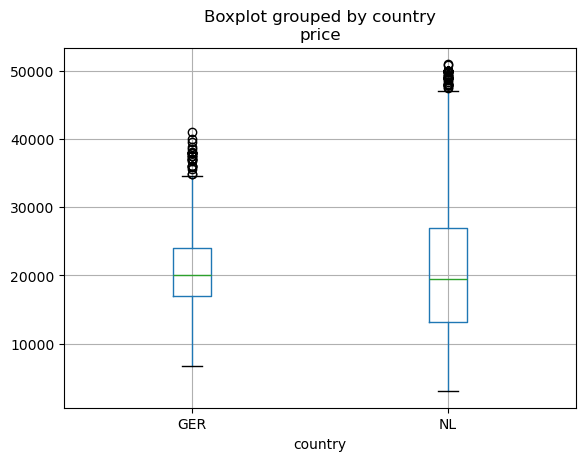

In [131]:
df.boxplot(column='price', by='country')

#### 3. Scatterplots, split by country

Text(0, 0.5, 'Price')

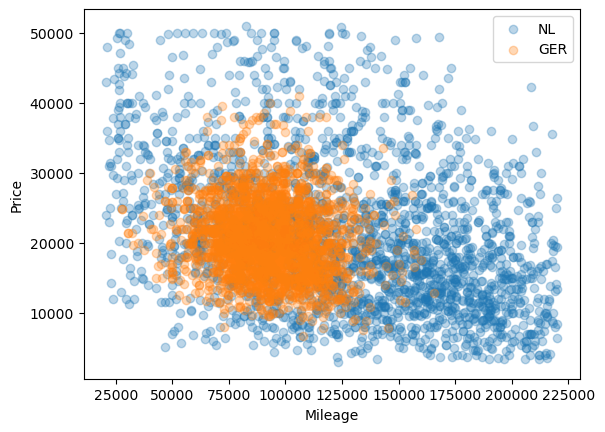

In [139]:
for c in df['country'].unique():
    subset = df[df['country'] == c]
    plt.scatter(subset['km'], subset['price'], label=c, alpha=0.3)

plt.legend()
plt.xlabel('Mileage')
plt.ylabel('Price')

#### 4. Boxplot: Price by fuel type AND country

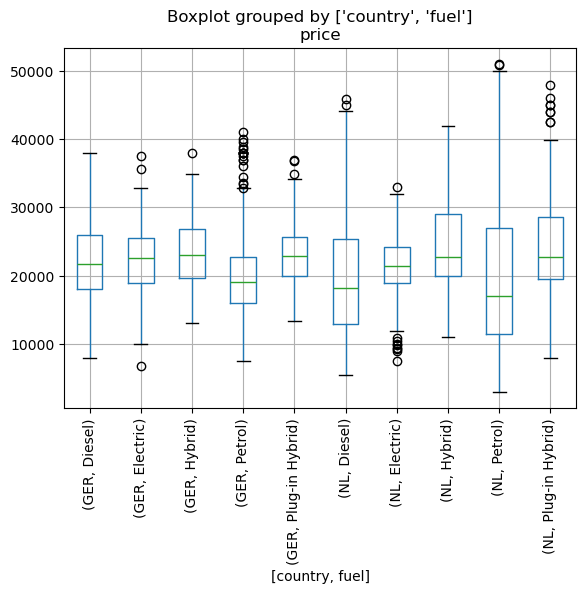

In [140]:
df.boxplot(column='price', by=['country', 'fuel'])
plt.xticks(rotation=90)
plt.show()

#### 5. group averages

In [134]:
df.groupby(['country', 'fuel'])[['price','km','age']].mean().round(2)

price         km   age
country fuel                                     
GER     Diesel          22084.26  101480.79  8.68
        Electric        22172.00   79361.65  4.75
        Hybrid          23184.60   87869.62  5.98
        Petrol          19557.39   93661.71  9.17
        Plug-in Hybrid  23085.57   87575.71  5.61
NL      Diesel          20028.66  140217.72  7.73
        Electric        21130.80   99174.42  5.24
        Hybrid          24223.23  106875.26  5.36
        Petrol          20206.01  129694.08  7.04
        Plug-in Hybrid  24390.33  117057.43  4.94

In [135]:
df.columns

Index(['title', 'previewImage', 'segment', 'category', 'brand', 'model', 'url',
       'price', 'createdDate', 'modifiedDate', 'renewedDate', 'description',
       'descriptionTranslated', 'attributes', 'features', 'batteryInformation',
       'images', 'rank', 'id', 'sellerId', 'priceRating', 'dealerDetails',
       'country', 'km', 'first_reg', 'age', 'fuel_raw', 'transmission',
       'fuel'],
      dtype='object')

In [136]:
# dropping some irrelavant info

df = df.drop(['previewImage', 'segment', 'category','url',
        'createdDate', 'modifiedDate', 'renewedDate', 'description',
       'descriptionTranslated','batteryInformation',
       'images', 'rank',  'sellerId', 'dealerDetails','first_reg'
       ], axis=1)

In [137]:
# 

df_filtered_for_regression = df.drop(['title', 'brand', 'model', 'attributes', 'features', 'priceRating', 'fuel_raw', 'id'],axis=1)

df_filtered_for_regression.to_json('data_prepared/regression_data_combined')
